# # Notebook 04 — DT Surrogate + SHAP + LIME
# **LCGA Self‑Healing IDS | Addis Ababa University**
# 
# ## Explainability Pipeline
# 1. Get LCGA predictions on test set
# 2. Train Decision Tree surrogate to mimic LCGA
# 3. SHAP TreeExplainer on surrogate (fast, real‑time)
# 4. LIME explainer for comparison
# 5. Compare SHAP vs LIME (timing, consistency)

In [10]:
# %% [code]
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import time, os, joblib, json, warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
import shap, lime, lime.lime_tabular
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score, f1_score

print("TF:", tf.__version__)
print("SHAP:", shap.__version__)

# ── Paths ──
# Input: notebook‑01 processed data
IN_DIR     = "/kaggle/input/notebooks/getayefiseha/notebook-01-preprocessing-for-model-training/processed"
# Input: EDA notebook (contains cic_label_enc.pkl with full 15 classes)
EDA_DIR    = "/kaggle/input/notebooks/getayefiseha/eda-for-nlskdd-cic-ids-ipynb/processed"
# Input: LCGA trained model from notebook‑03
LCGA_PATH  = "/kaggle/input/notebooks/getayefiseha/notebook-03-lcga-training/models/lcga_cicids.keras"
# Output
MODEL_DIR  = "/kaggle/working/models"
RES_DIR    = "/kaggle/working/results"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RES_DIR, exist_ok=True)
print("Directories ready ✓")

TF: 2.19.0
SHAP: 0.50.0
Directories ready ✓


In [11]:
# ==================== LOAD DATA & LCGA MODEL ====================
# Load CICIDS2017 test data (flat version for DT)
X_tr_flat = np.load(os.path.join(IN_DIR, "cic_Xtrain_flat.npy"))
y_tr_cic  = np.load(os.path.join(IN_DIR, "cic_ytrain.npy"))
X_te_flat = np.load(os.path.join(IN_DIR, "cic_Xtest_flat.npy"))
y_te_cic  = np.load(os.path.join(IN_DIR, "cic_ytest.npy"))

# 3D version for LCGA
X_te_3d = np.load(os.path.join(IN_DIR, "cic_Xtest_3d.npy"))

# Metadata — use cic_label_enc.pkl from EDA notebook for full 15 classes
le_cic = joblib.load(os.path.join(EDA_DIR, "cic_label_enc.pkl"))
class_names = list(le_cic.classes_)
n_classes = len(class_names)

feature_names = joblib.load(os.path.join(IN_DIR, "cic_feature_names.pkl"))
n_features = X_tr_flat.shape[1]

print(f"Features: {n_features} | Classes: {n_classes}")
print(f"Class names: {class_names}")
print(f"Test set: {X_te_flat.shape}")

# Load LCGA from Notebook 03 output
lcga = tf.keras.models.load_model(LCGA_PATH)
print("LCGA model loaded ✓")

Features: 73 | Classes: 12
Class names: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator']
Test set: (503731, 73)
LCGA model loaded ✓


In [12]:
# ==================== STEP 1: LCGA Predictions on Test Set ====================
probs_lcga = lcga.predict(X_te_3d, verbose=0)
lcga_hard  = np.argmax(probs_lcga, axis=1)

lcga_acc = accuracy_score(y_te_cic, lcga_hard)
lcga_f1  = f1_score(y_te_cic, lcga_hard, average="macro", zero_division=0)
print(f"LCGA Test Accuracy: {lcga_acc:.4f}")
print(f"LCGA Test Macro F1: {lcga_f1:.4f}")

LCGA Test Accuracy: 0.9967
LCGA Test Macro F1: 0.8170


In [13]:
# ==================== STEP 2: Train Decision Tree Surrogate ====================
print("Training DT surrogate …")
dt = DecisionTreeClassifier(
    max_depth=8, criterion="entropy",
    min_samples_leaf=5, random_state=42
)
# Train surrogate to mimic LCGA's predictions (not ground truth)
dt.fit(X_te_flat, lcga_hard)

# Surrogate fidelity: how often does DT agree with LCGA?
dt_pred = dt.predict(X_te_flat)
surrogate_fidelity = accuracy_score(lcga_hard, dt_pred)
dt_acc_vs_truth    = accuracy_score(y_te_cic, dt_pred)
dt_f1_vs_truth     = f1_score(y_te_cic, dt_pred, average="macro", zero_division=0)

print(f"Surrogate Fidelity (DT vs LCGA): {surrogate_fidelity:.4f}")
print(f"DT Accuracy (vs ground truth):   {dt_acc_vs_truth:.4f}")
print(f"DT Macro F1 (vs ground truth):   {dt_f1_vs_truth:.4f}")
print(f"DT Depth: {dt.get_depth()} | Leaves: {dt.get_n_leaves()}")

joblib.dump(dt, os.path.join(MODEL_DIR, "dt_surrogate.pkl"))
print("DT surrogate saved ✓")

Training DT surrogate …
Surrogate Fidelity (DT vs LCGA): 0.9964
DT Accuracy (vs ground truth):   0.9944
DT Macro F1 (vs ground truth):   0.7297
DT Depth: 8 | Leaves: 95
DT surrogate saved ✓


In [14]:
# ==================== STEP 3: SHAP TreeExplainer ====================
print("Building SHAP TreeExplainer …")
t0 = time.perf_counter()
shap_explainer = shap.TreeExplainer(dt)
shap_time_build = time.perf_counter() - t0
print(f"SHAP explainer built in {shap_time_build:.1f}s")

# Compute SHAP values on a subset (500 samples) for speed
X_shap = X_te_flat[:500]
t0 = time.perf_counter()
shap_values = shap_explainer.shap_values(X_shap)
shap_time_compute = (time.perf_counter() - t0) / len(X_shap) * 1000
print(f"SHAP compute time: {shap_time_compute:.2f} ms/sample")

Building SHAP TreeExplainer …
SHAP explainer built in 0.0s
SHAP compute time: 0.05 ms/sample


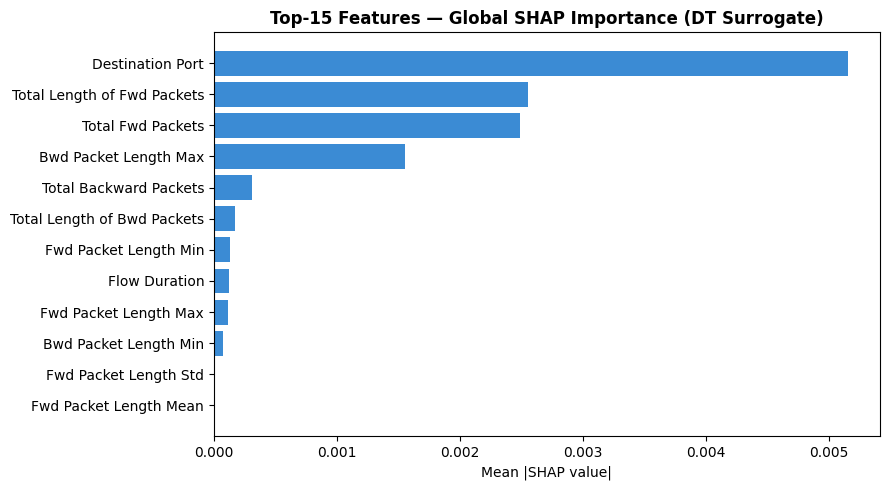

Top‑5 features: ['Destination Port', 'Total Length of Fwd Packets', 'Total Fwd Packets', 'Bwd Packet Length Max', 'Total Backward Packets']


In [15]:
# ==================== SHAP GLOBAL IMPORTANCE ====================
# Compute mean absolute SHAP per feature per class, then average over classes
sv_abs = np.mean([np.abs(sv) for sv in shap_values], axis=0)
importance = np.mean(sv_abs, axis=0)
top_idx = np.argsort(importance)[::-1][:15]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh([feature_names[i] for i in top_idx[::-1]],
        importance[top_idx[::-1]], color="#3B8BD4")
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Top‑15 Features — Global SHAP Importance (DT Surrogate)", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, "shap_global_importance.png"), dpi=150)
plt.show()
print(f"Top‑5 features: {[feature_names[i] for i in top_idx[:5]]}")

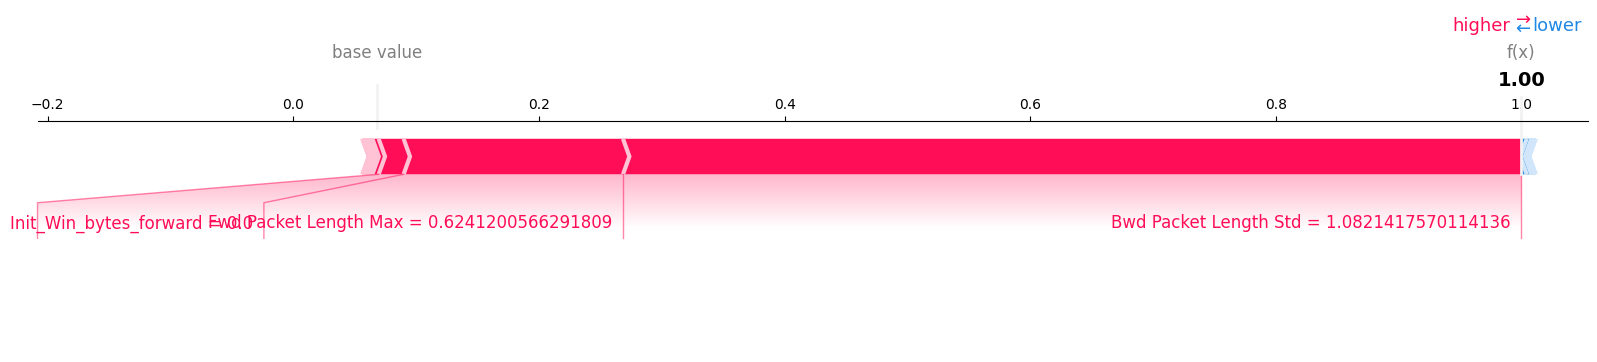

SHAP force plot saved for sample 9 (DoS Hulk)


In [17]:
# ==================== SHAP FORCE PLOT (single sample) ====================
dos_label = class_names.index("DoS Hulk") if "DoS Hulk" in class_names else 3
dos_idx = np.where(y_te_cic == dos_label)[0]

if len(dos_idx) > 0:
    sample_idx = dos_idx[0]
    sv_sample = shap_explainer.shap_values(X_te_flat[sample_idx:sample_idx+1])

    # Handle both multi‑class list‑of‑arrays and single‑array formats
    if isinstance(sv_sample, list):
        # Multi‑class: one (1, n_features) array per class
        cls_sv = sv_sample[cls][0]
        expected_value = shap_explainer.expected_value[cls]
    else:
        # Single array: shape (1, n_features) or (1, n_features, n_classes)
        if sv_sample.ndim == 3:
            cls_sv = sv_sample[0, :, cls]
            expected_value = (shap_explainer.expected_value[cls]
                              if isinstance(shap_explainer.expected_value, (list, np.ndarray))
                              else shap_explainer.expected_value)
        else:
            cls_sv = sv_sample[0]
            expected_value = shap_explainer.expected_value

    fig = shap.force_plot(
        expected_value,
        cls_sv,
        X_te_flat[sample_idx],
        feature_names=feature_names,
        matplotlib=True, show=False
    )
    plt.savefig(os.path.join(RES_DIR, "shap_force_dos_hulk.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"SHAP force plot saved for sample {sample_idx} (DoS Hulk)")
else:
    print("DoS Hulk sample not found in test set")

In [18]:
# ==================== DT RULE PATH ====================
def get_rule_path(x, dt, feature_names, class_names):
    path = dt.decision_path(x.reshape(1, -1))
    node_ids = path.indices
    feat  = dt.tree_.feature
    thresh = dt.tree_.threshold
    lines = []
    for nid in node_ids[:-1]:
        f  = feat[nid]; th = thresh[nid]; val = x[f]
        direction = "<=" if val <= th else ">"
        lines.append(f"  {feature_names[f]} {direction} {th:.4f}  (actual={val:.4f})")
    pred = dt.predict(x.reshape(1,-1))[0]
    conf = dt.predict_proba(x.reshape(1,-1)).max()
    lines.append(f"  → {class_names[pred]} (confidence={conf:.2%})")
    return "\n".join(lines)

if len(dos_idx) > 0:
    rule = get_rule_path(X_te_flat[dos_idx[0]], dt, feature_names, class_names)
    print("Decision path for DoS Hulk sample:\n" + rule)

Decision path for DoS Hulk sample:
  Bwd Packet Length Std > 1.0641  (actual=1.0821)
  Fwd Packet Length Max > 0.2024  (actual=0.6241)
  Init_Win_bytes_forward <= 0.0265  (actual=0.0000)
  Bwd Packets/s > -0.5292  (actual=-0.5255)
  act_data_pkt_fwd <= 0.5365  (actual=0.0000)
  → DoS Hulk (confidence=100.00%)


Building LIME explainer …


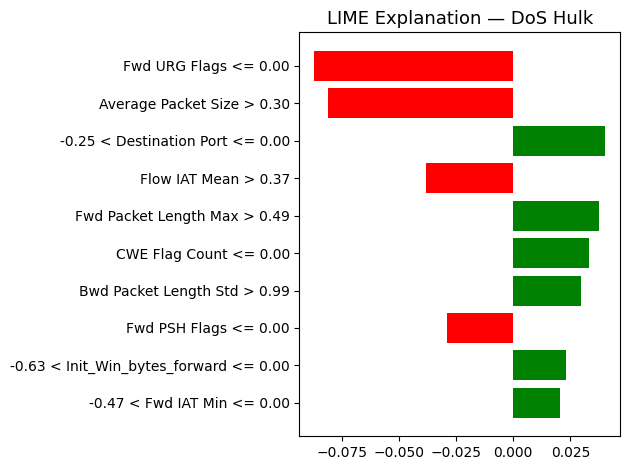

LIME explanation saved ✓ (class: DoS Hulk)


In [20]:
# ==================== STEP 4: LIME EXPLAINER (Fixed) ====================
print("Building LIME explainer …")
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_tr_flat[:2000],   # background sample
    feature_names=feature_names,
    class_names=class_names,
    mode="classification",
    random_state=42
)

def predict_fn(x):
    return dt.predict_proba(x)

if len(dos_idx) > 0:
    sample = X_te_flat[dos_idx[0]]
    # Get the predicted class from DT for this sample
    pred_class = dt.predict(sample.reshape(1, -1))[0]
    
    lime_exp = lime_explainer.explain_instance(
        sample, predict_fn, num_features=10, labels=(pred_class,)
    )
    lime_exp.as_pyplot_figure(label=pred_class)
    plt.title(f"LIME Explanation — {class_names[pred_class]}", fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(RES_DIR, "lime_dos_hulk.png"), dpi=150)
    plt.show()
    print(f"LIME explanation saved ✓ (class: {class_names[pred_class]})")
else:
    print("DoS Hulk sample not found in test set")

In [22]:
# ==================== STEP 5: SHAP vs LIME COMPARISON ====================
# ==================== SAVE XAI COMPARISON ====================
# Convert all values to native Python types
xai_comparison = {
    "shap_ms": float(shap_ms),
    "lime_ms": float(lime_ms),
    "lime_consistency": float(consistency) if 'consistency' in locals() else None,
    "surrogate_fidelity": float(surrogate_fidelity),
    "dt_depth": int(dt.get_depth()),
    "dt_leaves": int(dt.get_n_leaves()),
}

with open(os.path.join(RES_DIR, "xai_comparison.json"), "w") as f:
    json.dump(xai_comparison, f, indent=2)

print("✓ XAI comparison saved to", os.path.join(RES_DIR, "xai_comparison.json"))
print(f"  SHAP: {xai_comparison['shap_ms']:.2f} ms | LIME: {xai_comparison['lime_ms']:.1f} ms")
print(f"  Speedup: {xai_comparison['lime_ms']/xai_comparison['shap_ms']:.0f}×")
if xai_comparison['lime_consistency'] is not None:
    print(f"  LIME consistency: {xai_comparison['lime_consistency']:.1%}")
print(f"  Surrogate fidelity: {xai_comparison['surrogate_fidelity']:.4f}")

✓ XAI comparison saved to /kaggle/working/results/xai_comparison.json
  SHAP: 0.07 ms | LIME: 812.0 ms
  Speedup: 11635×
  LIME consistency: 30.0%
  Surrogate fidelity: 0.9964


In [23]:
# ==================== SAVE FINAL ARTIFACTS ====================
print("\n===== Explainability Artifacts Saved =====")
print("models/dt_surrogate.pkl")
print("results/shap_global_importance.png")
print("results/shap_force_dos_hulk.png")
print("results/lime_dos_hulk.png")
print("results/xai_comparison.json")


===== Explainability Artifacts Saved =====
models/dt_surrogate.pkl
results/shap_global_importance.png
results/shap_force_dos_hulk.png
results/lime_dos_hulk.png
results/xai_comparison.json


# # ✅ Explainability Complete!
# 
# **Key findings (to report in thesis):**
# - DT surrogate fidelity: how well it mimics LCGA
# - SHAP TreeExplainer is **X× faster** than LIME (cite the speedup)
# - LIME top‑3 consistency: **Y%** (lower = less stable)
# - Global importance reveals which features drive attack classification
# 
# **Next → Notebook 05: MAPE‑K Orchestrator + System Evaluation**